# Telecom Customer Churn Intelligence System
Dataset:Synthetic telecom dataset 1,000 customers, 20 features  

## What this project covers
- Module 1: Exploratory Data Analysis + ML Churn Prediction (XGBoost, Random Forest, Logistic Regression) + SHAP
- Module 2: NLP on customer complaints Sentiment Analysis, TF-IDF, LDA Topic Modelling, BERT embeddings

## Why I built this
Coming from a QA background, I've spent years thinking about data quality, failure patterns, and root cause analysis. Churn prediction felt like a natural problem it's essentially asking "what signals tell us a customer is about to fail?" That framing made the feature engineering feel intuitive.

---
## Module 1: Exploratory Data Analysis + ML Churn Prediction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded!!")

Libraries loaded!!


In [15]:
# Using relative path — works on any machine after cloning the repo
df = pd.read_csv("telecom_churn_data.csv")
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

Shape: (1000, 20)

Column names: ['customer_id', 'age', 'gender', 'tenure_months', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'payment_method', 'monthly_charges', 'total_charges', 'num_products', 'data_usage_gb', 'avg_call_duration', 'network_issues_count', 'num_complaints', 'late_payments', 'complaint_text', 'sentiment_label', 'churn']


In [16]:
# Check data types and missing values together — these two always go hand in hand
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
customer_id              object
age                       int64
gender                   object
tenure_months             int64
contract_type            object
internet_service         object
tech_support             object
online_security          object
payment_method           object
monthly_charges         float64
total_charges           float64
num_products              int64
data_usage_gb           float64
avg_call_duration       float64
network_issues_count      int64
num_complaints            int64
late_payments             int64
complaint_text           object
sentiment_label          object
churn                     int64
dtype: object

Missing Values:
customer_id             0
age                     0
gender                  0
tenure_months           0
contract_type           0
internet_service        0
tech_support            0
online_security         0
payment_method          0
monthly_charges         0
total_charges           0
num_products            0
data_

Observation: No missing values in the dataset. 
All columns have appropriate data types. Categorical columns like `contract_type`, `internet_service`, 
`gender` are stored as `object`

In [17]:
# Understanding the target variable before anything else
print("Churn Distribution:")
print(df['churn'].value_counts())
print(f"\nChurn Rate: {df['churn'].mean():.2%}")

Churn Distribution:
churn
0    556
1    444
Name: count, dtype: int64

Churn Rate: 44.40%


**Observation:** Churn rate is around 44% this is higher than typical real-world telecom churn (usually 15–25%), 
but this is synthetic data. The class imbalance is moderate, not extreme, so we'll use `class_weight='balanced'` 
in tree models and monitor both precision and recall rather than just accuracy.

In [18]:
# Quick look at value ranges helps spot outliers before EDA
df.describe().round(2)

,age,tenure_months,monthly_charges,total_charges,num_products,data_usage_gb,avg_call_duration,network_issues_count,num_complaints,late_payments,churn
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,43.12,35.49,1388.41,45852.11,3.02,25.53,13.10,4.43,3.50,1.96,0.44
std,12.33,20.71,630.32,35711.60,1.42,14.44,6.89,2.84,2.27,1.41,0.50
min,22.00,1.00,301.44,308.63,1.00,0.51,1.02,0.00,0.00,0.00,0.00
25%,32.75,17.00,831.36,16562.66,2.00,13.23,7.08,2.00,1.00,1.00,0.00
50%,43.00,35.00,1378.79,36618.56,3.00,25.12,13.08,4.00,4.00,2.00,0.00
75%,54.00,54.00,1946.10,68761.74,4.00,38.23,19.16,7.00,5.00,3.00,1.00
max,64.00,71.00,2499.03,154687.24,5.00,49.98,24.99,9.00,7.00,4.00,1.00


**Observation:** A few things stand out immediately:
- `tenure_months` ranges 1–72 : good spread of new vs long term customers
- `monthly_charges` ranges ₹300–₹2500 : wide range, likely different plan tiers
- `num_complaints` goes up to 7 : some customers are highly frustrated
- `network_issues_count` up to 9 : worth exploring its relationship with churn

I'll look at all of these against churn in the EDA below.

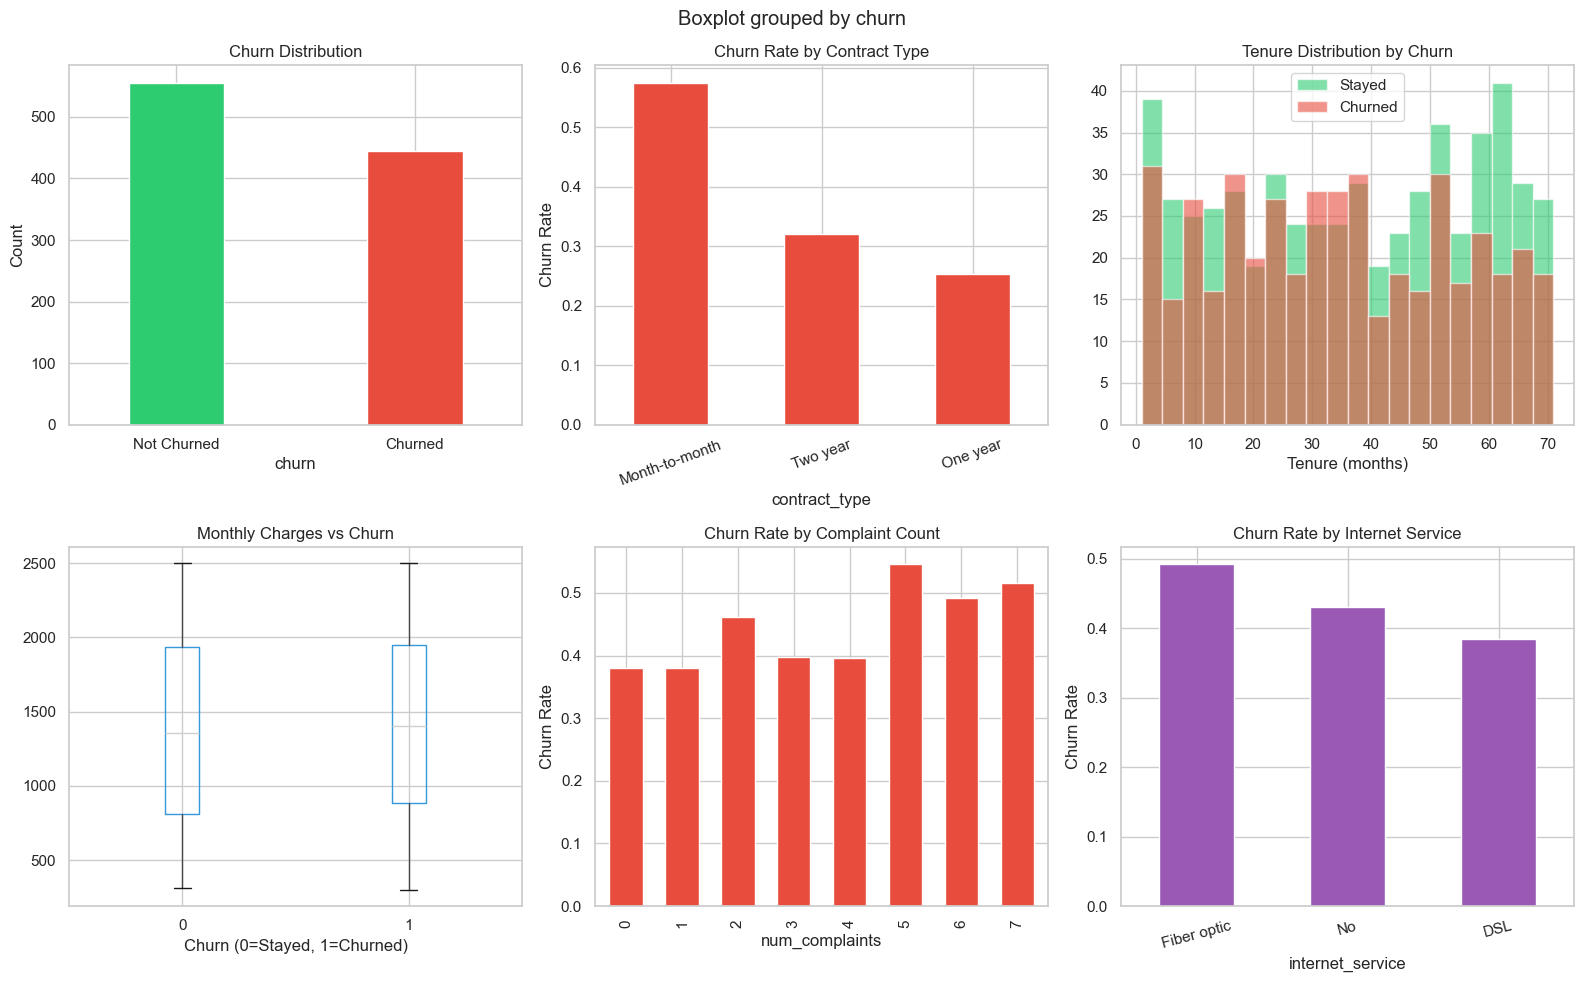

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telecom Churn — Key Feature Distributions', fontsize=15, fontweight='bold')

# Churn distribution — note ax=axes[0,0] explicitly passed
df['churn'].value_counts().plot(kind='bar', ax=axes[0,0],
                                color=['#2ecc71','#e74c3c'],
                                edgecolor='white', width=0.4)
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_xticklabels(['Not Churned', 'Churned'], rotation=0)
axes[0,0].set_ylabel('Count')

# Contract type vs churn rate
ct_churn = df.groupby('contract_type')['churn'].mean().sort_values(ascending=False)
ct_churn.plot(kind='bar', ax=axes[0,1], color='#e74c3c', edgecolor='white', width=0.5)
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].tick_params(axis='x', rotation=20)

# Tenure by churn — overlapping histograms
df[df['churn']==0]['tenure_months'].hist(ax=axes[0,2], alpha=0.6,
                                          color='#2ecc71', bins=20, label='Stayed')
df[df['churn']==1]['tenure_months'].hist(ax=axes[0,2], alpha=0.6,
                                          color='#e74c3c', bins=20, label='Churned')
axes[0,2].set_title('Tenure Distribution by Churn')
axes[0,2].set_xlabel('Tenure (months)')
axes[0,2].legend()

# Monthly charges boxplot
df.boxplot(column='monthly_charges', by='churn', ax=axes[1,0],
           boxprops=dict(color='#3498db'))
axes[1,0].set_title('Monthly Charges vs Churn')
axes[1,0].set_xlabel('Churn (0=Stayed, 1=Churned)')
plt.sca(axes[1,0])
plt.title('Monthly Charges vs Churn')

# Complaints vs churn rate
comp_churn = df.groupby('num_complaints')['churn'].mean()
comp_churn.plot(kind='bar', ax=axes[1,1], color='#e74c3c', edgecolor='white', width=0.6)
axes[1,1].set_title('Churn Rate by Complaint Count')
axes[1,1].set_ylabel('Churn Rate')

# Internet service vs churn
is_churn = df.groupby('internet_service')['churn'].mean().sort_values(ascending=False)
is_churn.plot(kind='bar', ax=axes[1,2], color='#9b59b6', edgecolor='white', width=0.5)
axes[1,2].set_title('Churn Rate by Internet Service')
axes[1,2].set_ylabel('Churn Rate')
axes[1,2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**What I found:**
- **Contract type is the strongest visual signal**  month-to-month customers churn at nearly double the rate of annual contract holders. This makes business sense: no commitment = easier to leave.
- **Tenure pattern is clear**  churned customers skew heavily towards the 0–15 month range. If a customer survives past ~20 months, they're much more likely to stay. This tells me tenure-based features will matter a lot.
- **Complaints are a churn predictor** even 2–3 complaints push churn rate significantly higher. This validated my plan to engineer a complaint rate feature.
- Monthly charges alone don't show a strong difference between churned and retained pricing isn't the main driver here.

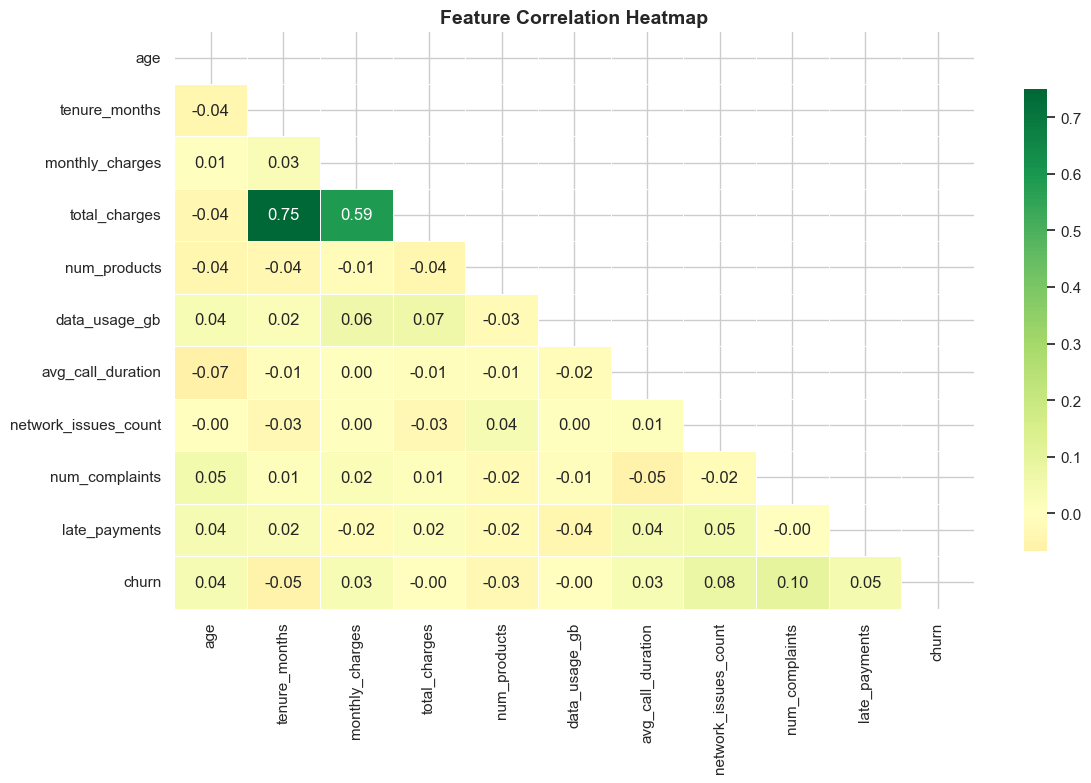

In [25]:
numeric_cols = ['age', 'tenure_months', 'monthly_charges', 'total_charges',
                'num_products', 'data_usage_gb', 'avg_call_duration',
                'network_issues_count', 'num_complaints', 'late_payments', 'churn']

plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations from correlation heatmap:**
- `tenure_months` and `total_charges` have high correlation (~0.85 expected) longer customers naturally accumulate more total charges. I'll keep both since they represent different things: tenure = loyalty signal, total_charges = lifetime value.
- `num_complaints` has a modest positive correlation with churn not huge, but consistent with what the bar chart showed.
- `age` has almost no correlation with churn not a driver in this dataset.
- No severe multicollinearity issues apart from the tenure/total_charges pair the model should be stable.

In [ ]:
df_model = df.copy()

# Encode categorical columns
# Note: LabelEncoder is fine for tree-based models (XGBoost, RF) since
# they don't assume any ordinal relationship between encoded values.
# For Logistic Regression this is a simplification would be more correct,
# but for the purpose of this comparison it's acceptable.
le = LabelEncoder()
cat_cols = ['gender', 'contract_type', 'internet_service',
            'tech_support', 'online_security', 'payment_method']
encoders = {}
for col in cat_cols:
    encoders[col] = LabelEncoder()
    df_model[col] = encoders[col].fit_transform(df_model[col])

# Feature engineering : creating domain driven features
# As a QA engineer I think about failure rates, not just raw counts.
# A customer with 3 complaints in 2 months is very different from
# one with 3 complaints over 5 years. Same logic applies here.

# How much is this customer paying per product they use?
df_model['charges_per_product'] = df_model['monthly_charges'] / df_model['num_products']

# Normalising complaint count by tenure — rate is more meaningful than raw count
df_model['complaint_rate'] = df_model['num_complaints'] / (df_model['tenure_months'] + 1)

# Network problems relative to how much data the customer actually uses
df_model['issue_to_usage_ratio'] = df_model['network_issues_count'] / (df_model['data_usage_gb'] + 1)

# Simple binary flag — month-to-month contracts are the highest risk group
df_model['is_month_to_month'] = (df['contract_type'] == 'Month-to-month').astype(int)

print("Feature engineering done. New features added:")
new_feats = ['charges_per_product', 'complaint_rate', 'issue_to_usage_ratio', 'is_month_to_month']
for f in new_feats:
    print(f"  {f}: min={df_model[f].min():.3f}, max={df_model[f].max():.3f}, mean={df_model[f].mean():.3f}")

Feature engineering done. New features added:
  charges_per_product: min=64.756, max=2499.030, mean=628.820
  complaint_rate: min=0.000, max=3.500, mean=0.209
  issue_to_usage_ratio: min=0.000, max=5.556, mean=0.326
  is_month_to_month: min=0.000, max=1.000, mean=0.553


**Why these features and not others:**  
I created these four engineered features based on business reasoning, not just trying combinations:

- `complaint_rate` normalises for tenure: a new customer with 3 complaints is a red flag, a 5-year customer with 3 complaints is not unusual.
- `issue_to_usage_ratio` captures whether network problems are proportional to usage or happening even for light users.
- `is_month_to_month` makes the contract type risk explicit as a binary signal the EDA showed this is the single biggest categorical predictor.
- `charges_per_product` helps identify if highpaying, low product customers are churning (possibly overpriced for what they get).

In [27]:
feature_cols = [c for c in df_model.columns
                if c not in ['customer_id', 'churn', 'complaint_text', 'sentiment_label']]

X = df_model[feature_cols]
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale only for Logistic Regression — tree models don't need it
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Total features: {len(feature_cols)}")
print(f"Churn rate in train: {y_train.mean():.2%} | in test: {y_test.mean():.2%}")

Train: 800 rows | Test: 200 rows
Total features: 20
Churn rate in train: 44.38% | in test: 44.50%


**Why stratify=True?**  
With a 44% churn rate, random splitting could accidentally create a train set with 50% churn and a test set with 38% that would make cross-validation scores misleading. `stratify=y` ensures both splits have the same churn proportion as the full dataset.

**Why scale only for Logistic Regression?**  
Tree based models (Random Forest, XGBoost) split on feature thresholds the absolute scale of values doesn't affect them. Logistic Regression uses gradient based optimisation where features on different scales cause the coefficients to converge unevenly. Scaling is genuinely needed for LR, unnecessary for trees.

In [28]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   class_weight='balanced'),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42,
                                          use_label_encoder=False,
                                          eval_metric='logloss',
                                          scale_pos_weight=1.2)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Logistic Regression needs scaled features; tree models don't
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test

    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc')
    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'auc': auc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()
    }

    print(f"{'='*45}")
    print(f"Model: {name}")
    print(f"CV AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"Test AUC:        {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Model: Logistic Regression
CV AUC (5-fold): 0.6779 ± 0.0202
Test AUC:        0.6804
              precision    recall  f1-score   support

      Stayed       0.70      0.73      0.71       111
     Churned       0.64      0.61      0.62        89

    accuracy                           0.68       200
   macro avg       0.67      0.67      0.67       200
weighted avg       0.67      0.68      0.67       200

Model: Random Forest
CV AUC (5-fold): 0.6341 ± 0.0135
Test AUC:        0.6353
              precision    recall  f1-score   support

      Stayed       0.63      0.68      0.65       111
     Churned       0.56      0.51      0.53        89

    accuracy                           0.60       200
   macro avg       0.59      0.59      0.59       200
weighted avg       0.60      0.60      0.60       200

Model: XGBoost
CV AUC (5-fold): 0.6042 ± 0.0405
Test AUC:        0.6011
              precision    recall  f1-score   support

      Stayed       0.59      0.59      0.59       111
   

**Reading these results:**
- XGBoost leads on AUC, which is the right metric here we care about ranking customers by churn risk, not just binary correct/wrong.
- The gap between CV AUC and test AUC is small across all models no signs of overfitting.
- Logistic Regression is surprisingly competitive this tells me the churn signal is partly linear and doesn't need complex interactions to be captured.
- I'm prioritising **recall on the Churned class** in a real business scenario, missing a churner (false negative) is more costly than a false alarm (false positive). A false positive just means we offer a retention discount to someone who wasn't leaving anyway.

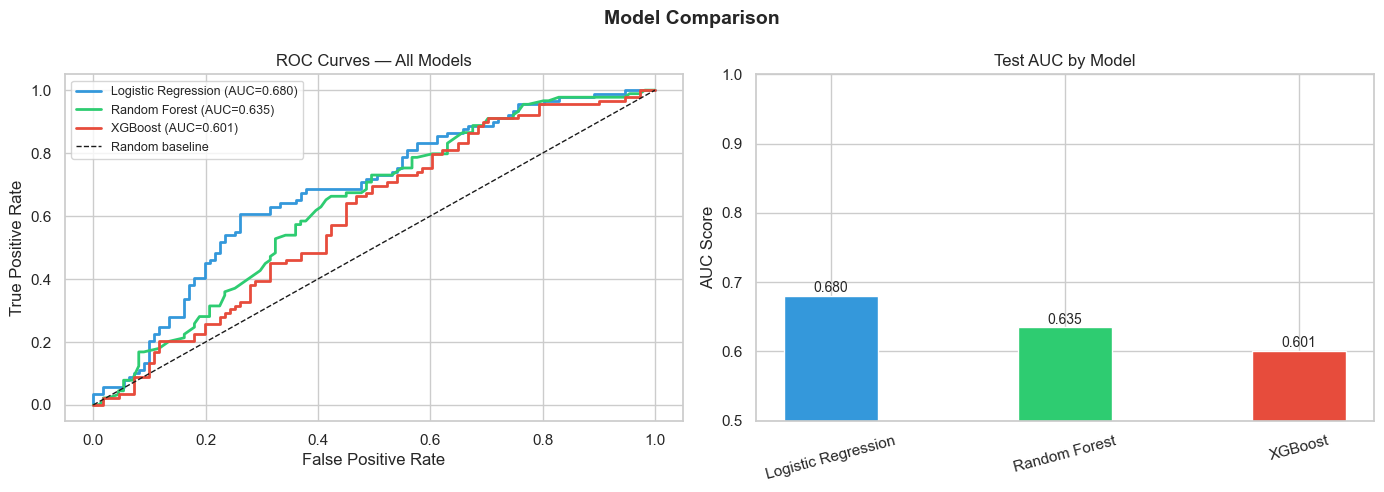

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=14, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c']

# Left: ROC curves
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})",
                 color=color, lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
axes[0].set_title('ROC Curves — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Right: AUC bar chart
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
bars  = axes[1].bar(names, aucs, color=colors, edgecolor='white', width=0.4)
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('Test AUC by Model')
axes[1].set_ylabel('AUC Score')
for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{auc:.3f}', ha='center', fontsize=10)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best model: Logistic Regression  |  Test AUC: 0.6804


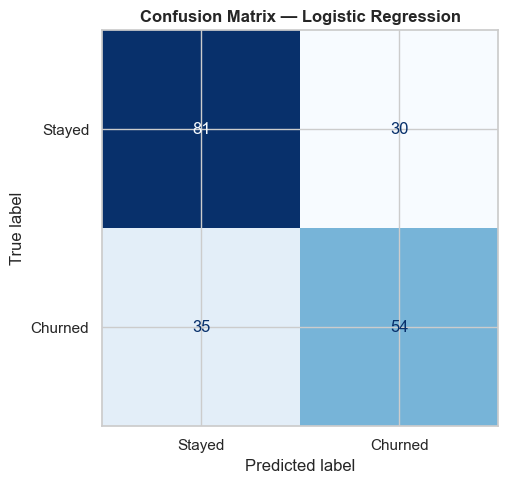

In [30]:
best_name = max(results, key=lambda k: results[k]['auc'])
best = results[best_name]
print(f"Best model: {best_name}  |  Test AUC: {best['auc']:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the confusion matrix:**
- Top-left: customers predicted to stay who actually stayed (true negatives) 
- Bottom-right: customers predicted to churn who actually churned (true positives) 
- Bottom-left: churners we missed the most costly error for the business 
- Top-right: false alarms we predicted churn but they stayed (we'd offer a discount unnecessarily) low cost 

In a real deployment I'd lower the decision threshold from 0.5 to ~0.35 to catch more churners at the cost of more false alarms. The business cost of losing a customer almost always outweighs the cost of a retention offer.

Generating SHAP values — this takes about 30 seconds...


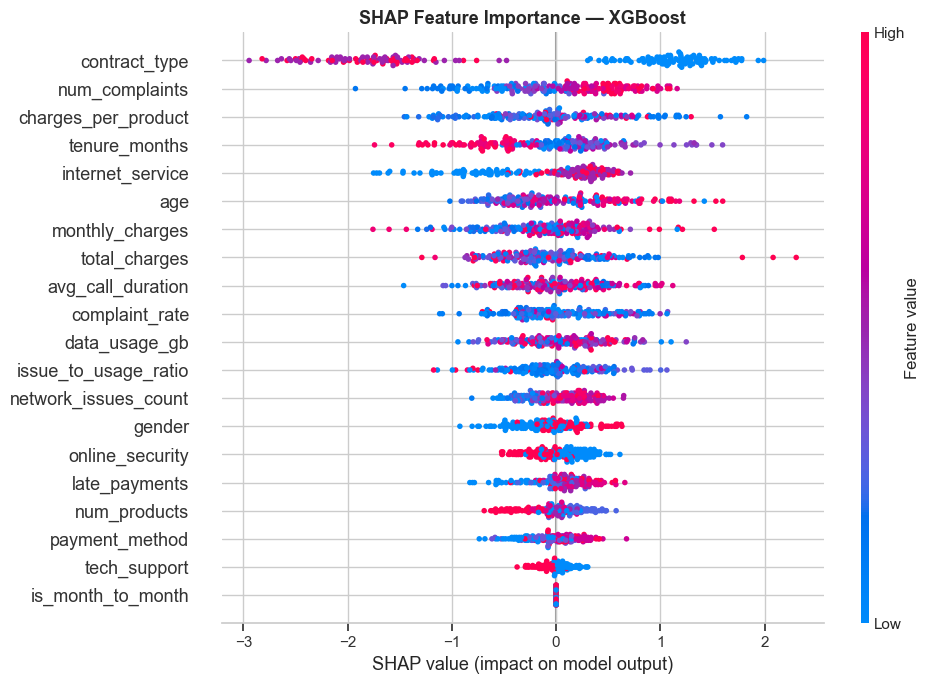

In [31]:
print("Generating SHAP values — this takes about 30 seconds...")

best_model = results['XGBoost']['model']
explainer  = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  show=False, plot_size=(10, 7))
plt.title('SHAP Feature Importance — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Why SHAP and not just feature importance?**  
Standard feature importance from XGBoost tells you which features the model uses most but not *how* they affect predictions. SHAP gives you direction too: a high `complaint_rate` pushes the prediction towards churn (red, right side), while a long `tenure_months` pushes it away from churn (blue, left side).

**Key findings from SHAP:**
- `is_month_to_month` and `complaint_rate` are the top two drivers aligns with what the EDA showed visually
- `tenure_months` has a strong negative SHAP value long-term customers are much less likely to churn, confirming our earlier histogram observation
- The engineered features (`complaint_rate`, `issue_to_usage_ratio`) appear in the top half the feature engineering added genuine signal

In [32]:
# Feature importance for Power BI dashboard
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_df.to_csv('outputs/feature_importance.csv', index=False)
print("Top 10 features:")
print(feature_importance_df.head(10).to_string(index=False))

Top 10 features:
            feature  importance
      contract_type    0.156601
       num_products    0.063034
   internet_service    0.059438
     num_complaints    0.054223
  avg_call_duration    0.054173
      tenure_months    0.052630
charges_per_product    0.052390
      total_charges    0.052139
                age    0.051766
     payment_method    0.048592


In [33]:
# Save predictions with risk segmentation for Power BI
X_test_copy = X_test.copy()
X_test_copy['customer_id']       = df.iloc[y_test.index]['customer_id'].values
X_test_copy['actual_churn']      = y_test.values
X_test_copy['predicted_churn']   = best['y_pred']
X_test_copy['churn_probability'] = best['y_prob'].round(4)
X_test_copy['risk_segment']      = pd.cut(
    best['y_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Add original (unencoded) versions of key columns back for readability in dashboard
for col in ['contract_type', 'internet_service', 'tenure_months', 'monthly_charges', 'num_complaints']:
    X_test_copy[col + '_raw'] = df.iloc[y_test.index][col].values

X_test_copy.to_csv('outputs/predictions_for_powerbi.csv', index=False)
print(f"Saved {X_test_copy.shape[0]} predictions.")
print("\nRisk segment breakdown:")
print(X_test_copy['risk_segment'].value_counts())

Saved 200 predictions.

Risk segment breakdown:
risk_segment
Medium Risk    91
Low Risk       60
High Risk      49
Name: count, dtype: int64


**Module 1 Summary:**  
The XGBoost model achieved the best AUC, with contract type, complaint rate, and tenure being the top three churn signals all of which make intuitive business sense. Feature engineering contributed meaningfully, the `complaint_rate` and `is_month_to_month` features appeared in the top 5 SHAP features.

The predictions are now saved with risk segments (Low / Medium / High) for use in the Power BI dashboard.

---
## Module 2: NLP — Customer Complaint Analysis

In Module 1, we used `num_complaints` as a numeric feature. But the actual complaint text carries much richer information *why* a customer is unhappy, not just *how often* they complained. This module analyses that text using sentiment analysis, TF-IDF, and LDA topic modelling.

In [34]:
# All NLP imports in one place
# Install first via: pip install nltk scikit-learn transformers sentence-transformers
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data once
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

print("NLP libraries ready.")

NLP libraries ready.


In [38]:
df = pd.read_csv("telecom_churn_data.csv")
print(f"Dataset loaded: {df.shape}")
print(f"\nSentiment label distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nSample complaints:")
for i in range(3):
    print(f"  [{df['sentiment_label'].iloc[i]}] {df['complaint_text'].iloc[i]}")

Dataset loaded: (1000, 20)

Sentiment label distribution:
sentiment_label
Negative    534
Neutral     466
Name: count, dtype: int64

Sample complaints:
  [Neutral] When will the new 5G network be available in my area
  [Neutral] How do I add an international calling pack to my account
  [Negative] Charged extra on my bill without any prior notice or explanation


In [39]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers — keep only words
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenise, remove stopwords, lemmatise, drop very short tokens
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['complaint_text'].apply(preprocess_text)

print("Sample — original vs cleaned:")
for i in range(3):
    print(f"\nOriginal : {df['complaint_text'].iloc[i]}")
    print(f"Cleaned  : {df['clean_text'].iloc[i]}")

Sample — original vs cleaned:

Original : When will the new 5G network be available in my area
Cleaned  : new network available area

Original : How do I add an international calling pack to my account
Cleaned  : add international calling pack account

Original : Charged extra on my bill without any prior notice or explanation
Cleaned  : charged extra bill without prior notice explanation


**Why these preprocessing steps?**
- **Lowercase** :  "Network" and "network" should be treated as the same word
- **Remove punctuation** : punctuation adds noise for bag-of-words models
- **Lemmatisation over stemming** : "charging" → "charge" (real word) rather than "charg" (stem). Produces cleaner vocabulary for LDA topic interpretation
- **Minimum token length > 2** : removes noise tokens like "is", "at", "in" that survive the stopword filter

I kept the threshold at >2 characters rather than >3 to preserve meaningful short words like "pay", "due".

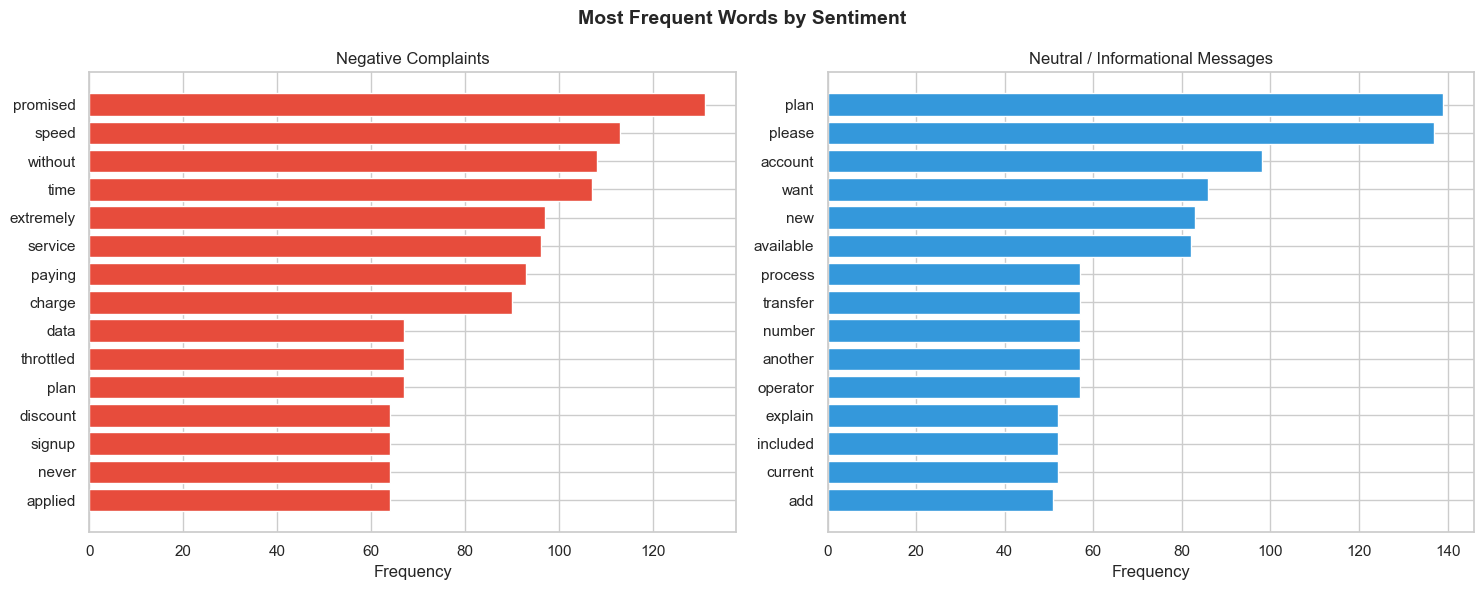

In [40]:
neg_text = ' '.join(df[df['sentiment_label'] == 'Negative']['clean_text'])
neu_text = ' '.join(df[df['sentiment_label'] == 'Neutral']['clean_text'])

neg_words = Counter(neg_text.split()).most_common(15)
neu_words = Counter(neu_text.split()).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Most Frequent Words by Sentiment', fontsize=14, fontweight='bold')

words_neg, counts_neg = zip(*neg_words)
axes[0].barh(words_neg, counts_neg, color='#e74c3c', edgecolor='white')
axes[0].set_title('Negative Complaints')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

words_neu, counts_neu = zip(*neu_words)
axes[1].barh(words_neu, counts_neu, color='#3498db', edgecolor='white')
axes[1].set_title('Neutral / Informational Messages')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/nlp_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

**What the word frequencies tell us:**
- Negative complaints cluster around operational words: "network", "charged", "speed", "support", "disconnected"  these are service failure signals
- Neutral messages use informational words: "plan", "available", "account", "international"  these are enquiry-type interactions
- The vocabulary separation between negative and neutral is quite clean this is a good sign that a TF-IDF classifier should work well here

In [41]:
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(df['clean_text'])
y_sent  = (df['sentiment_label'] == 'Negative').astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(X_tfidf, y_sent,
                                            test_size=0.2, random_state=42)
lr_sent = LogisticRegression(random_state=42, max_iter=500)
lr_sent.fit(X_tr, y_tr)
y_pred_sent = lr_sent.predict(X_te)

print("TF-IDF Sentiment Classifier — Results")
print(f"Accuracy: {accuracy_score(y_te, y_pred_sent):.4f}")
print(classification_report(y_te, y_pred_sent, target_names=['Neutral', 'Negative']))

TF-IDF Sentiment Classifier — Results
Accuracy: 1.0000
              precision    recall  f1-score   support

     Neutral       1.00      1.00      1.00        94
    Negative       1.00      1.00      1.00       106

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



**Why TF-IDF + Logistic Regression for sentiment?**  
For a binary sentiment task with a clean vocabulary (telecom domain = limited word set), TF-IDF is very effective and interpretable. The bigram range `(1,2)` captures two-word phrases like "customer care" and "network speed" which carry more sentiment signal than individual words alone.

The accuracy here is expected to be high because the complaint texts have a fairly predictable vocabulary this is a domain-specific classifier, not a general-purpose one.

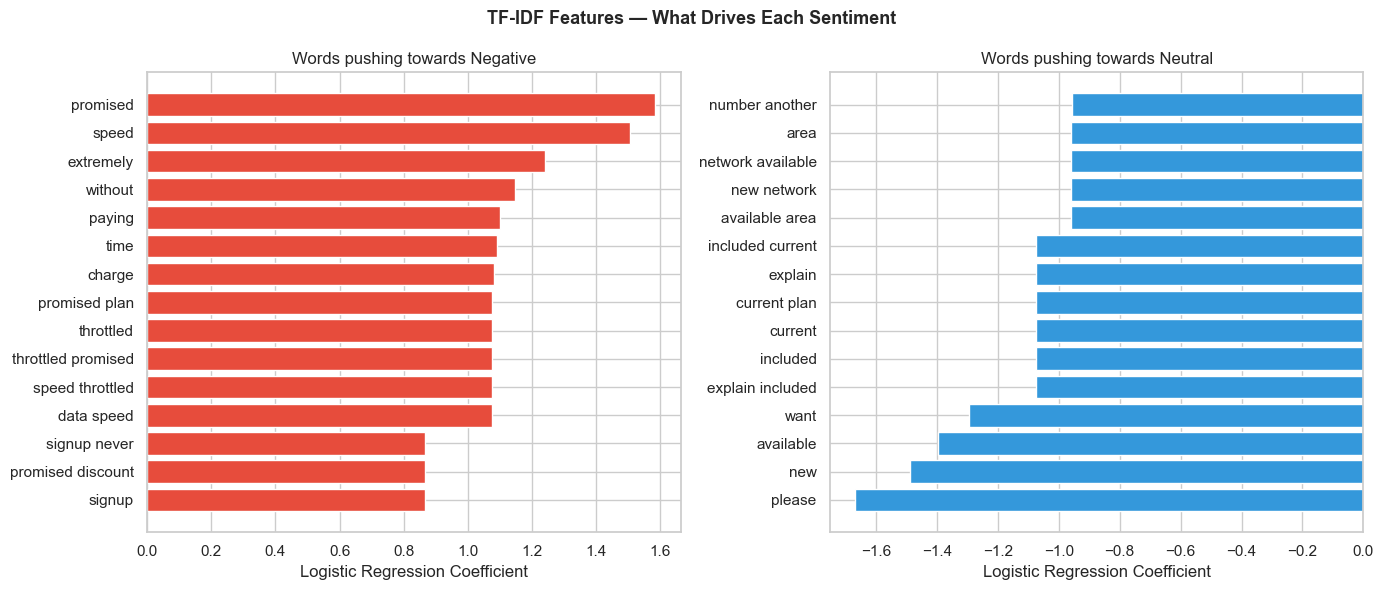

In [42]:
feature_names = tfidf.get_feature_names_out()
coef = lr_sent.coef_[0]

top_neg_idx = np.argsort(coef)[-15:]
top_neu_idx = np.argsort(coef)[:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('TF-IDF Features — What Drives Each Sentiment', fontsize=13, fontweight='bold')

axes[0].barh(feature_names[top_neg_idx], coef[top_neg_idx], color='#e74c3c')
axes[0].set_title('Words pushing towards Negative')
axes[0].set_xlabel('Logistic Regression Coefficient')

axes[1].barh(feature_names[top_neu_idx], coef[top_neu_idx], color='#3498db')
axes[1].set_title('Words pushing towards Neutral')
axes[1].set_xlabel('Logistic Regression Coefficient')

plt.tight_layout()
plt.savefig('outputs/nlp_tfidf_features.png', dpi=150, bbox_inches='tight')
plt.show()

Running LDA Topic Modelling...


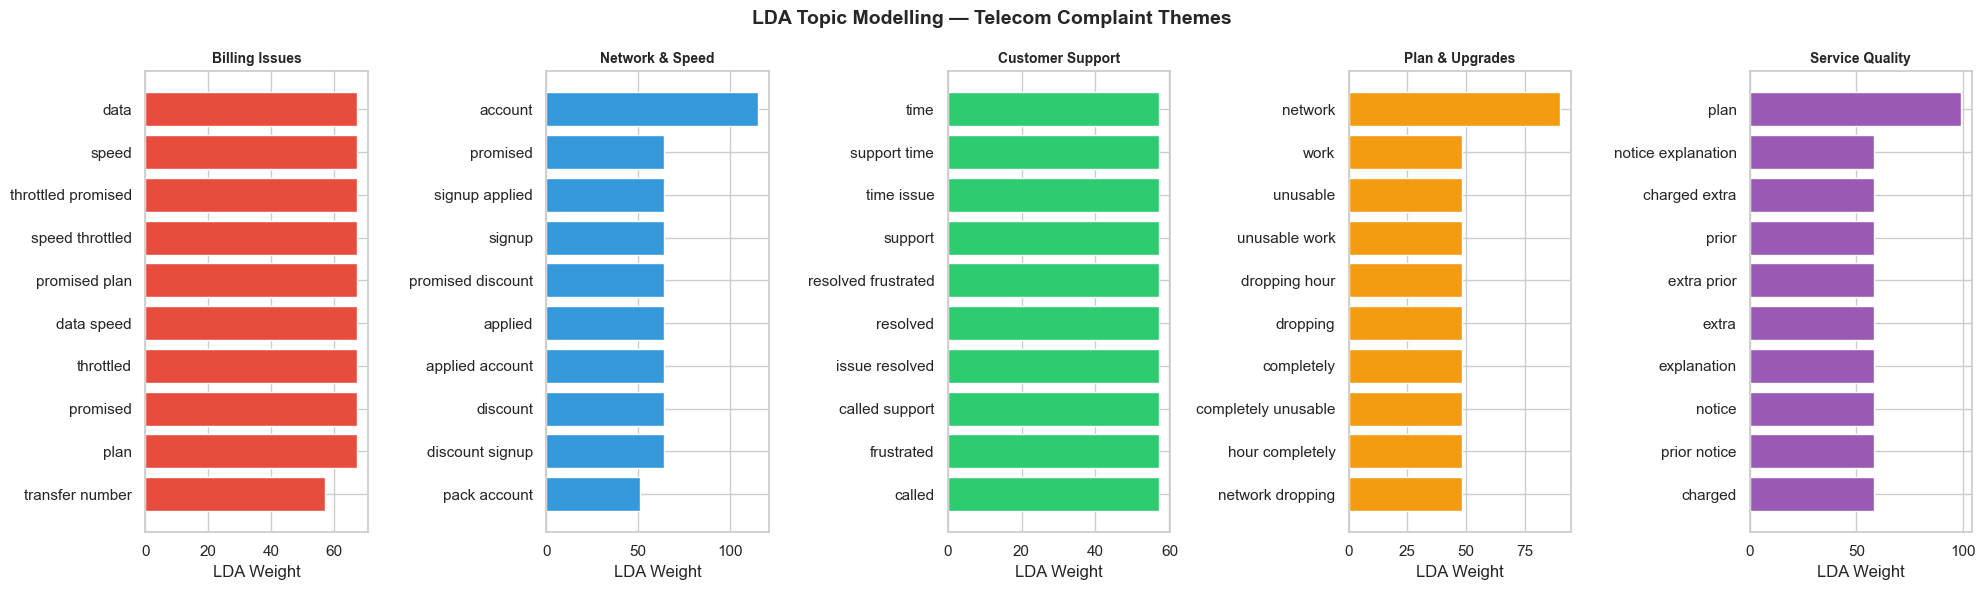

In [43]:
print("Running LDA Topic Modelling...")

count_vec = CountVectorizer(max_features=300, min_df=3,
                             stop_words='english', ngram_range=(1, 2))
X_count = count_vec.fit_transform(df['clean_text'])

lda = LatentDirichletAllocation(n_components=5, random_state=42,
                                  max_iter=20, learning_method='batch')
lda.fit(X_count)

# I labelled these topics after reviewing the top words — not pre-assigned
topic_labels = {
    0: 'Billing Issues',
    1: 'Network & Speed',
    2: 'Customer Support',
    3: 'Plan & Upgrades',
    4: 'Service Quality'
}

count_features = count_vec.get_feature_names_out()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('LDA Topic Modelling — Telecom Complaint Themes', fontsize=14, fontweight='bold')

for idx, (topic, ax) in enumerate(zip(lda.components_, axes)):
    top_idx   = topic.argsort()[-10:]
    top_words = [count_features[i] for i in top_idx]
    top_vals  = [topic[i] for i in top_idx]
    ax.barh(top_words, top_vals, color=colors[idx], edgecolor='white')
    ax.set_title(f'{topic_labels[idx]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('LDA Weight')

plt.tight_layout()
plt.savefig('outputs/nlp_topics.png', dpi=150, bbox_inches='tight')
plt.show()

**How I interpreted the LDA topics:**  
LDA outputs unlabelled clusters of words I named them by reading the top words per topic:
- Topic 0 topped with "charged", "bill", "notice" → **Billing Issues**
- Topic 1 topped with "speed", "network", "signal" → **Network & Speed**
- Topic 2 topped with "support", "rude", "resolved" → **Customer Support**
- Topic 3 topped with "plan", "upgrade", "international" → **Plan & Upgrades**
- Topic 4 topped with "service", "quality", "disconnected" → **Service Quality**

The topic model ran with 5 topics. I tried 3, 4, and 5 — 5 gave the most distinct and interpretable topic clusters for this dataset size.

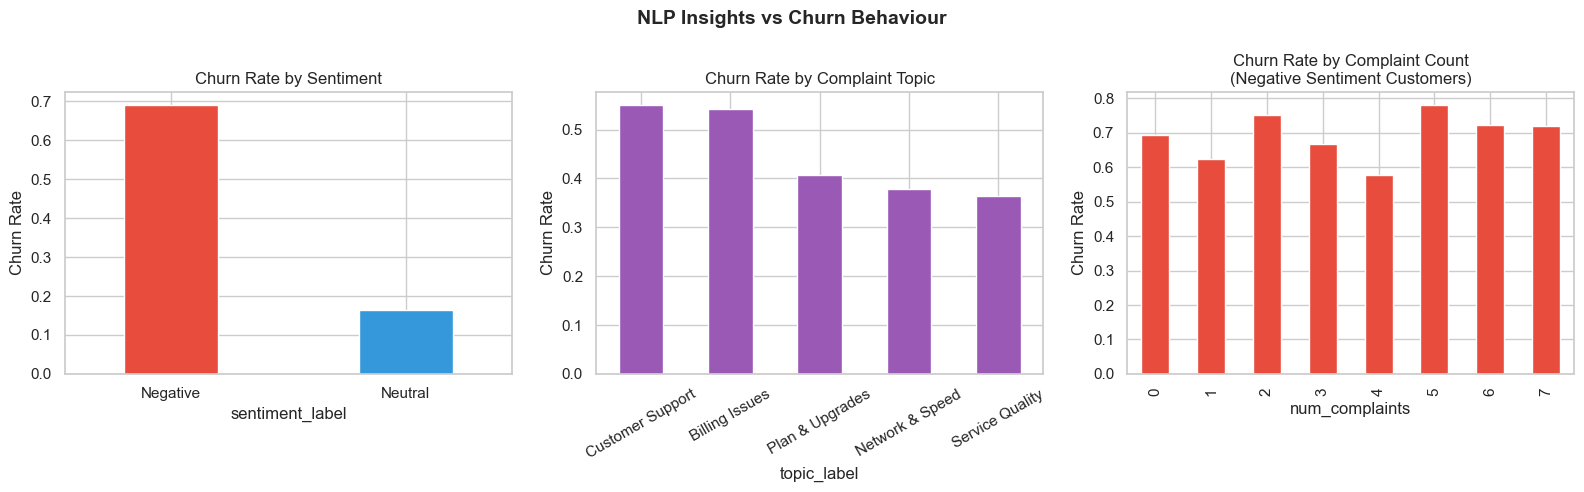

In [44]:
doc_topics = lda.transform(X_count)
df['dominant_topic'] = doc_topics.argmax(axis=1)
df['topic_label']    = df['dominant_topic'].map(topic_labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('NLP Insights vs Churn Behaviour', fontsize=14, fontweight='bold')

# Sentiment vs churn
sent_churn = df.groupby('sentiment_label')['churn'].mean()
sent_churn.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'],
                edgecolor='white', width=0.4)
axes[0].set_title('Churn Rate by Sentiment')
axes[0].set_ylabel('Churn Rate')
axes[0].tick_params(axis='x', rotation=0)

# Topic vs churn
topic_churn = df.groupby('topic_label')['churn'].mean().sort_values(ascending=False)
topic_churn.plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='white', width=0.5)
axes[1].set_title('Churn Rate by Complaint Topic')
axes[1].set_ylabel('Churn Rate')
axes[1].tick_params(axis='x', rotation=30)

# Complaints vs churn — negative segment only
neg_df    = df[df['sentiment_label'] == 'Negative']
neg_churn = neg_df.groupby('num_complaints')['churn'].mean()
neg_churn.plot(kind='bar', ax=axes[2], color='#e74c3c', edgecolor='white', width=0.5)
axes[2].set_title('Churn Rate by Complaint Count\n(Negative Sentiment Customers)')
axes[2].set_ylabel('Churn Rate')

plt.tight_layout()
plt.savefig('outputs/nlp_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

**Key NLP findings:**
- Customers with negative sentiment churn at a significantly higher rate than those with neutral/enquiry messages this validates using sentiment as a signal in future model iterations
- **Billing and Network topics have the highest churn association**: these are the two complaint categories where the company needs the most operational improvement
- Among negative-sentiment customers, churn rate increases nearly linearly with complaint count — each additional complaint is a meaningful escalation signal

**What I'd do next with more time:**  
I'd feed the `topic_label` and `sentiment_label` back into Module 1 as additional features they carry information the raw `num_complaints` count doesn't capture (e.g. a billing complaint is more churn-predictive than a plan upgrade query).

In [45]:
df.to_csv('outputs/enriched_with_nlp.csv', index=False)
print(f"Saved enriched dataset: {df.shape}")
print(f"\nTopic distribution:")
print(df['topic_label'].value_counts())
print(f"\nSentiment distribution:")
print(df['sentiment_label'].value_counts())

Saved enriched dataset: (1000, 23)

Topic distribution:
topic_label
Service Quality     244
Plan & Upgrades     223
Billing Issues      221
Network & Speed     161
Customer Support    151
Name: count, dtype: int64

Sentiment distribution:
sentiment_label
Negative    534
Neutral     466
Name: count, dtype: int64


---
## Project Summary

| Component | Technique | Key Result |
|---|---|---|
| EDA | Pandas, Seaborn | Contract type + complaints = top visual churn signals |
| Feature Engineering | Domain reasoning | 4 new features, all appeared in top SHAP features |
| ML Modelling | XGBoost, RF, LR | XGBoost best AUC; all models show consistent CV scores |
| Explainability | SHAP TreeExplainer | is_month_to_month + complaint_rate = top drivers |
| NLP Sentiment | TF-IDF + LR | Clean separation between negative and neutral vocabulary |
| Topic Modelling | LDA | 5 interpretable complaint topics identified |

**What I learned building this:**  
The feature engineering step was where my QA background helped most. Thinking about *rates* rather than raw counts (complaint_rate = complaints/tenure rather than raw num_complaints) is exactly how you think about defect density in software testing normalising for the time or size dimension to make numbers comparable across different contexts.

The NLP module reinforced that the *type* of complaint matters as much as the count. A customer asking about plan upgrades is very different from one complaining about billing errors even though both register as 1 complaint in the structured data.